In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from dataclasses import dataclass, field
from typing import Dict, Callable, Tuple, List
from __future__ import annotations

# --- Configuration & Constants ---
class Config:
    DAILY_INSTALLS_BASE = 20000
    DAILY_INSTALLS_OLD = 12000
    DAILY_INSTALLS_NEW = 8000
    
    ASSUMED_ARPPU = 1.00  # Stated assumption for IAP price
    SWITCH_DAY = 20       # Day when the new user source is added
    SIMULATION_DAYS = 30  # Duration of the analysis

    # Visualization Settings
    FIG_SIZE = (10, 6)
    COLOR_A = '#1f77b4' # Blue
    COLOR_B = '#ff7f0e' # Orange

print("Configuration loaded.")

Configuration loaded.


In [32]:
# ============================================================
# Mathematical Models + Helpers
# ============================================================

def exponential_decay_a(retention_day: int) -> float:
    """New Source Retention Formula for A (interpreted as D1, D2, ...)."""
    return 0.58 * np.exp(-0.12 * (retention_day - 1))


def exponential_decay_b(retention_day: int) -> float:
    """New Source Retention Formula for B (interpreted as D1, D2, ...)."""
    return 0.52 * np.exp(-0.10 * (retention_day - 1))


def clamp01(x: float) -> float:
    return max(0.0, min(float(x), 1.0))


def safe_log(x: float, eps: float = 1e-12) -> float:
    """Avoid log(0)."""
    return float(np.log(max(float(x), eps)))


def interp_log_space(x: float, x0: float, y0: float, x1: float, y1: float) -> float:
    """
    Interpolate y(x) between (x0,y0) and (x1,y1) linearly in log-space:
      log(y) = lerp(log(y0), log(y1))
    """
    if x1 == x0:
        return float(y0)
    t = (x - x0) / (x1 - x0)
    ly0, ly1 = safe_log(y0), safe_log(y1)
    ly = ly0 + t * (ly1 - ly0)
    return float(np.exp(ly))


def estimate_tail_lambda(d0: int, r0: float, d1: int, r1: float) -> float:
    """
    Estimate exponential decay rate lambda from two points:
      r1 = r0 * exp(-lambda*(d1-d0))  => lambda = -ln(r1/r0)/(d1-d0)
    """
    r0 = max(float(r0), 1e-12)
    r1 = max(float(r1), 1e-12)
    if d1 <= d0:
        return 0.0
    ratio = r1 / r0
    lam = -np.log(max(ratio, 1e-12)) / float(d1 - d0)
    return float(max(lam, 0.0))


# ============================================================
# Variant (Data + Retention Behavior)
# ============================================================

@dataclass
class Variant:
    """
    Convention:
      - retention_model[0] = 1.0  (same-day activity; D0)
      - known_retention keys are retention days (e.g., 1,3,7,14)
      - get_retention(age_day) returns retention at cohort age day (0,1,2,...)
    """
    name: str
    daily_purchase_ratio: float
    ecpm: float
    ad_imp_dau: float
    known_retention: Dict[int, float]
    retention_model: Dict[int, float] = field(default_factory=dict)

    def fit_retention_curve(self, days: int = 30) -> None:
        """
        Build retention_model[0..days] using:
          - Piecewise log-space interpolation between known points (D1/D3/D7/D14)
          - Exponential tail after the last known point (rate from last two known points)
        This is simple, deterministic, and easy to justify.
        """
        if not self.known_retention:
            raise ValueError("known_retention must not be empty")

        pts = sorted((int(d), float(r)) for d, r in self.known_retention.items())

        # Validate
        for d, r in pts:
            if d < 1:
                raise ValueError("known_retention days should be >= 1 (e.g., D1, D3, D7, D14)")
            if not (0.0 <= r <= 1.0):
                raise ValueError("known_retention rates must be within [0,1]")

        # Tail lambda from last two known points
        if len(pts) >= 2:
            (d0, r0), (d1, r1) = pts[-2], pts[-1]
            tail_lambda = estimate_tail_lambda(d0, r0, d1, r1)
            last_day, last_ret = d1, r1
        else:
            # Fallback if only one known point (unlikely here)
            tail_lambda = 0.10
            last_day, last_ret = pts[-1]

        self.retention_model = {0: 1.0}

        def retention_at_day(d: int) -> float:
            # Exact known points
            for kd, kr in pts:
                if d == kd:
                    return kr

            # Before first known point: linear interpolation between (0,1.0) and (first_day, first_ret)
            first_day, first_ret = pts[0]
            if d < first_day:
                t = d / float(first_day)
                return clamp01(1.0 + t * (first_ret - 1.0))

            # Between known points: log-space interpolation
            for (dl, rl), (dr, rr) in zip(pts[:-1], pts[1:]):
                if dl < d < dr:
                    return clamp01(interp_log_space(d, dl, rl, dr, rr))

            # After last known point: exponential tail
            if d > last_day:
                return clamp01(last_ret * np.exp(-tail_lambda * (d - last_day)))

            return 0.0

        # Fill 1..days with monotonic guard (retention shouldn't increase with age)
        prev = 1.0
        for d in range(1, days + 1):
            r = float(retention_at_day(d))
            if r > prev:
                r = prev
            self.retention_model[d] = clamp01(r)
            prev = self.retention_model[d]

    def get_retention(self, age_day: int) -> float:
        return float(self.retention_model.get(int(age_day), 0.0))


# ============================================================
# Simulator (Business Logic)
# ============================================================

class RevenueSimulator:
    @staticmethod
    def calculate_dau_single_stream(
        variant: Variant,
        calendar_day: int,
        daily_installs: int,
    ) -> float:
        """
        DAU on a given calendar_day with constant daily installs.

        Convention:
          - calendar_day starts at 1.
          - On calendar_day=t, existing cohort ages are 0..t-1.
        """
        if calendar_day < 1:
            return 0.0

        dau = 0.0
        for age in range(calendar_day):  # 0..t-1 (no phantom cohort)
            dau += daily_installs * variant.get_retention(age)
        return dau

    @staticmethod
    def run_mixed_cohort_simulation(
        variant: Variant,
        new_retention_func: Callable[[int], float],
        simulation_days: int,
        switch_day: int,
        total_installs_pre_switch: int,
        old_installs_post_switch: int,
        new_installs_post_switch: int,
        assumed_arppu: float,
    ) -> Tuple[float, List[float]]:
        """
        Mixed-cohort simulation:
          - Before switch_day (install_date < switch_day): all installs use original retention.
          - From switch_day onward (install_date >= switch_day): installs split into:
                old_installs_post_switch using original retention
                new_installs_post_switch using new_retention_func

        Switch interpretation:
          - switch_day is the FIRST day the new regime applies.
        """
        # Precompute new-source retention by cohort age
        new_retention_map: Dict[int, float] = {0: 1.0}
        for age in range(1, simulation_days + 1):
            new_retention_map[age] = clamp01(new_retention_func(age))

        cumulative_revenue = 0.0
        revenue_history: List[float] = []

        for current_day in range(1, simulation_days + 1):
            daily_dau = 0.0

            # Sum cohorts that exist today: ages 0..current_day-1
            for age in range(current_day):
                install_date = current_day - age  # 1..current_day

                if install_date < switch_day:
                    users = total_installs_pre_switch * variant.get_retention(age)
                else:
                    users_old = old_installs_post_switch * variant.get_retention(age)
                    users_new = new_installs_post_switch * new_retention_map.get(age, 0.0)
                    users = users_old + users_new

                daily_dau += users

            # Daily revenue
            iap_rev = daily_dau * variant.daily_purchase_ratio * assumed_arppu
            ad_rev = daily_dau * variant.ad_imp_dau * variant.ecpm / 1000.0

            cumulative_revenue += (iap_rev + ad_rev)
            revenue_history.append(cumulative_revenue)

        return cumulative_revenue, revenue_history


print("✅ Loaded: improved retention modeling + RevenueSimulator (correct cohort indexing).")


✅ Loaded: improved retention modeling + RevenueSimulator (correct cohort indexing).


In [33]:
class Visualizer:
    @staticmethod
    def plot_retention_fit(variant: Variant, color):
        """Plots actual data points vs the fitted curve."""
        days = list(variant.retention_model.keys())
        rates = list(variant.retention_model.values())
        
        plt.plot(days, rates, linestyle='--', color=color, alpha=0.7, label=f'{variant.name} (Fit)')
        plt.scatter(list(variant.known_retention.keys()), 
                   list(variant.known_retention.values()), 
                   color=color, s=80, zorder=5, label=f'{variant.name} (Actual)')

    @staticmethod
    def plot_revenue_race(history_a, history_b, title):
        """Plots the cumulative revenue comparison."""
        days = range(1, len(history_a) + 1)
        
        plt.figure(figsize=Config.FIG_SIZE)
        plt.plot(days, history_a, label='Variant A', color=Config.COLOR_A, linewidth=2)
        plt.plot(days, history_b, label='Variant B', color=Config.COLOR_B, linewidth=2)
        
        # Highlight the gap
        plt.fill_between(days, history_a, history_b, color='gray', alpha=0.1)
        
        plt.title(title, fontsize=14)
        plt.xlabel('Days Since Launch', fontsize=12)
        plt.ylabel('Cumulative Revenue ($)', fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    @staticmethod
    def plot_dau_trend(days, dau_trend_a, dau_trend_b):
        """Plots the DAU trend for both variants over a range of days."""
        plt.figure(figsize=Config.FIG_SIZE)
        plt.plot(days, dau_trend_a, label='Variant A', color=Config.COLOR_A)
        plt.plot(days, dau_trend_b, label='Variant B', color=Config.COLOR_B)
        plt.title("Daily Active Users (DAU) Projection")
        plt.xlabel("Day")
        plt.ylabel("Active Users")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


    @staticmethod
    def plot_bar_comparison(labels, base_values, comparison_values, base_label, comparison_label, title, ylabel):
        """
        Plots a bar chart comparing two sets of values (e.g., base vs. comparison).
        
        Args:
            labels (List[str]): Labels for the x-axis (e.g., ['Variant A', 'Variant B']).
            base_values (List[float]): Values for the base scenario.
            comparison_values (List[float]): Values for the comparison scenario.
            base_label (str): Label for the base scenario.
            comparison_label (str): Label for the comparison scenario.
            title (str): Title of the plot.
            ylabel (str): Label for the y-axis.
        """
        x = range(len(labels))
        width = 0.35

        plt.figure(figsize=Config.FIG_SIZE)
        plt.bar([i - width / 2 for i in x], base_values, width, label=base_label, color=Config.COLOR_A)
        plt.bar([i + width / 2 for i in x], comparison_values, width, label=comparison_label, color='green')
        plt.xticks(x, labels)
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        plt.grid(axis='y', alpha=0.3)
        plt.show()

    @staticmethod
    def plot_option_comparison(options: Dict[str, float], title: str, ylabel: str):
        """
        Plots a bar chart comparing multiple options.

        Args:
            options (Dict[str, float]): A dictionary where keys are option names and values are revenues.
            title (str): Title of the plot.
            ylabel (str): Label for the y-axis.
        """
        labels = list(options.keys())
        values = list(options.values())
        colors = ['gray', 'green', 'blue']  # Customize colors for each bar

        plt.figure(figsize=Config.FIG_SIZE)
        bars = plt.bar(labels, values, color=colors)
        plt.title(title, fontsize=14)
        plt.ylabel(ylabel, fontsize=12)
        plt.ylim(min(values) * 0.95, max(values) * 1.05)

        # Add value labels on top of bars
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2., height,
                     f'${int(height):,}',
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

        plt.grid(axis='y', alpha=0.3)
        plt.show()

----

A)

--- Task (a): DAU at Day 15 ---
Variant A: 73,591 users
Variant B: 76,179 users
WINNER: Variant B


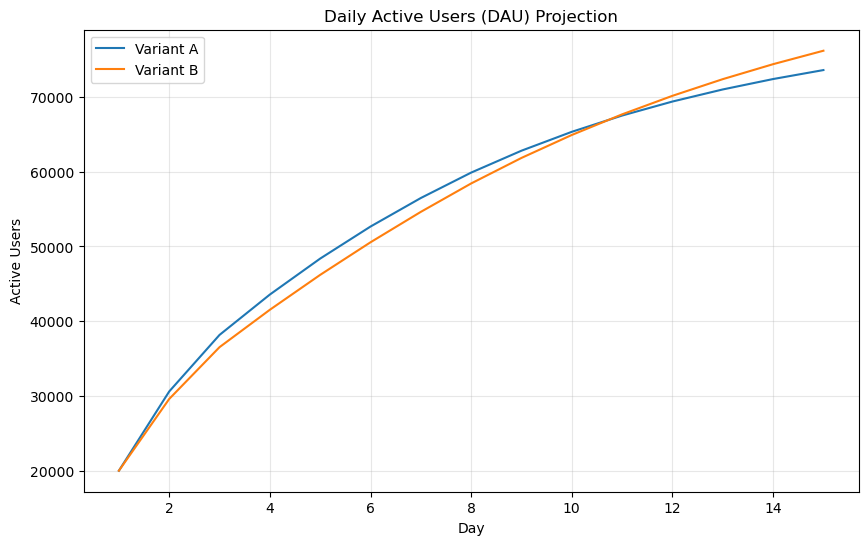

In [34]:
# --- Cell (a): Setup + DAU @ Day 15 ---

# Constants (edit if needed)
DAILY_INSTALLS_BASE = 20000
ASSUMED_ARPPU = 1.0

# 1) Initialize Variants (from prompt)
var_a = Variant(
    name="Variant A",
    daily_purchase_ratio=0.0305,
    ecpm=9.80,
    ad_imp_dau=2.3,
    known_retention={1: 0.53, 3: 0.27, 7: 0.17, 14: 0.06}
)

var_b = Variant(
    name="Variant B",
    daily_purchase_ratio=0.0315,
    ecpm=10.80,
    ad_imp_dau=1.6,
    known_retention={1: 0.48, 3: 0.25, 7: 0.19, 14: 0.09}
)

# 2) Fit retention curves
var_a.fit_retention_curve(days=30)
var_b.fit_retention_curve(days=30)

# 3) Calculate DAU at Day 15
day_target = 15
dau_a = RevenueSimulator.calculate_dau_single_stream(var_a, calendar_day=day_target, daily_installs=DAILY_INSTALLS_BASE)
dau_b = RevenueSimulator.calculate_dau_single_stream(var_b, calendar_day=day_target, daily_installs=DAILY_INSTALLS_BASE)

# 4) Output
print(f"--- Task (a): DAU at Day {day_target} ---")
print(f"{var_a.name}: {int(dau_a):,} users")
print(f"{var_b.name}: {int(dau_b):,} users")
print(f"WINNER: {var_b.name if dau_b > dau_a else var_a.name}")

# 5) Visualize DAU Trend (Day 1-15)
days = list(range(1, 16))
dau_trend_a = [RevenueSimulator.calculate_dau_single_stream(var_a, d, DAILY_INSTALLS_BASE) for d in days]
dau_trend_b = [RevenueSimulator.calculate_dau_single_stream(var_b, d, DAILY_INSTALLS_BASE) for d in days]

Visualizer.plot_dau_trend(days, dau_trend_a, dau_trend_b)

B)

--- Task (b): Total Revenue by Day 15 ---
Variant A: $44,115.44
Variant B: $40,241.71
WINNER: Variant A


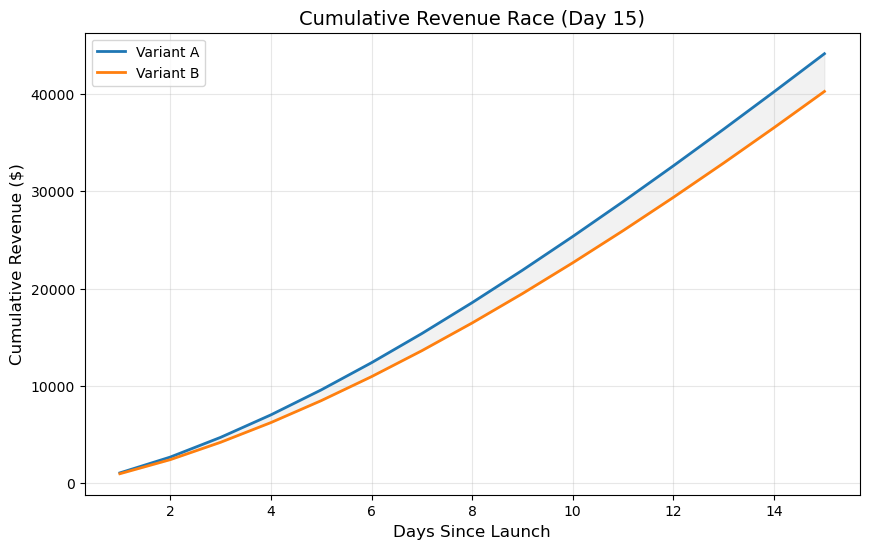

In [35]:
# --- Cell (b): Total Revenue by Day 15 (Baseline) ---

def run_basic_revenue_sim(variant: Variant, days: int, daily_installs: int, assumed_arppu: float):
    """Cumulative revenue under baseline conditions (single-stream installs)."""
    cumulative = 0.0
    history = []
    for d in range(1, days + 1):
        dau = RevenueSimulator.calculate_dau_single_stream(variant, calendar_day=d, daily_installs=daily_installs)

        iap = dau * variant.daily_purchase_ratio * assumed_arppu
        ad = dau * variant.ad_imp_dau * variant.ecpm / 1000.0

        cumulative += (iap + ad)
        history.append(cumulative)
    return cumulative, history

rev_a_15, hist_a_15 = run_basic_revenue_sim(var_a, days=15, daily_installs=DAILY_INSTALLS_BASE, assumed_arppu=ASSUMED_ARPPU)
rev_b_15, hist_b_15 = run_basic_revenue_sim(var_b, days=15, daily_installs=DAILY_INSTALLS_BASE, assumed_arppu=ASSUMED_ARPPU)

print(f"--- Task (b): Total Revenue by Day 15 ---")
print(f"{var_a.name}: ${rev_a_15:,.2f}")
print(f"{var_b.name}: ${rev_b_15:,.2f}")
print(f"WINNER: {var_a.name if rev_a_15 > rev_b_15 else var_b.name}")

Visualizer.plot_revenue_race(hist_a_15, hist_b_15, "Cumulative Revenue Race (Day 15)")


C)

--- Task (c): Total Revenue by Day 30 ---
Variant A: $106,408.85
Variant B: $102,150.01
WINNER: Variant A


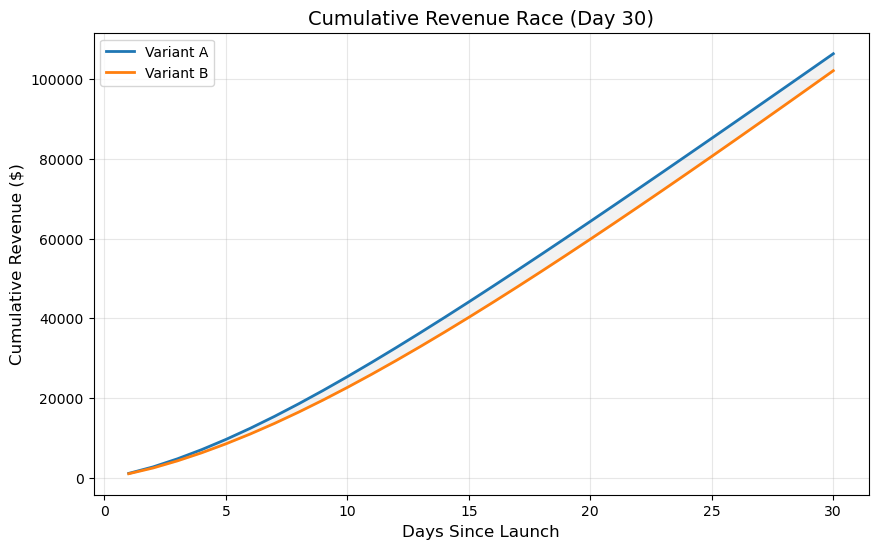

In [36]:
# --- Cell (c): Total Revenue by Day 30 (Baseline) ---

rev_a_30, hist_a_30 = run_basic_revenue_sim(var_a, days=30, daily_installs=DAILY_INSTALLS_BASE, assumed_arppu=ASSUMED_ARPPU)
rev_b_30, hist_b_30 = run_basic_revenue_sim(var_b, days=30, daily_installs=DAILY_INSTALLS_BASE, assumed_arppu=ASSUMED_ARPPU)

print(f"--- Task (c): Total Revenue by Day 30 ---")
print(f"{var_a.name}: ${rev_a_30:,.2f}")
print(f"{var_b.name}: ${rev_b_30:,.2f}")
print(f"WINNER: {var_a.name if rev_a_30 > rev_b_30 else var_b.name}")

Visualizer.plot_revenue_race(hist_a_30, hist_b_30, "Cumulative Revenue Race (Day 30)")

D)

--- Task (d): Revenue with 10-Day Sale (Day 30) ---
Variant A (Sale): $114,097.20
Variant B (Sale): $110,330.33
WINNER: Variant A


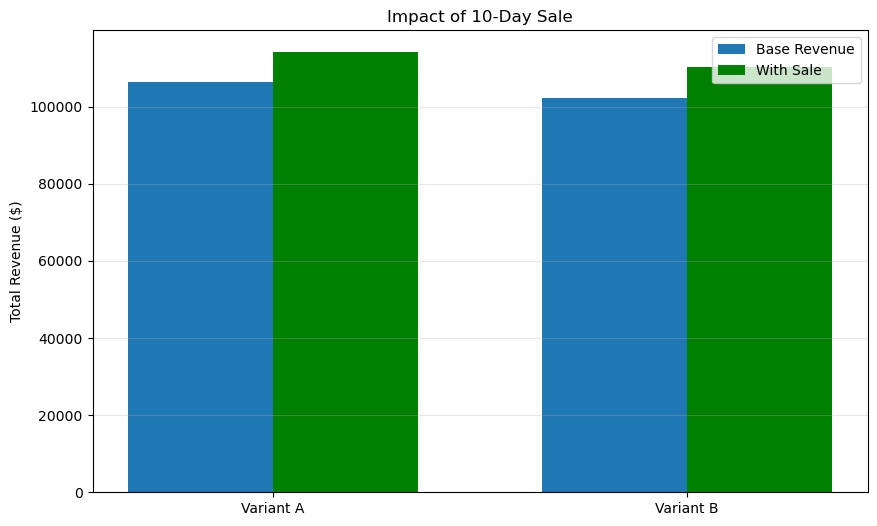

In [37]:
# --- Cell (d): 10-Day Sale Simulation (Day 15-24), Revenue by Day 30 ---

def run_sale_simulation(
    variant: Variant,
    daily_installs: int,
    assumed_arppu: float,
    days: int = 30,
    sale_start: int = 15,
    sale_duration: int = 10,
    purchase_boost: float = 0.01,
):
    cumulative = 0.0
    sale_end = sale_start + sale_duration - 1  # inclusive

    for d in range(1, days + 1):
        dau = RevenueSimulator.calculate_dau_single_stream(variant, calendar_day=d, daily_installs=daily_installs)

        current_purchase_ratio = variant.daily_purchase_ratio
        if sale_start <= d <= sale_end:
            current_purchase_ratio += purchase_boost

        iap = dau * current_purchase_ratio * assumed_arppu
        ad = dau * variant.ad_imp_dau * variant.ecpm / 1000.0

        cumulative += (iap + ad)

    return cumulative

sale_rev_a = run_sale_simulation(var_a, daily_installs=DAILY_INSTALLS_BASE, assumed_arppu=ASSUMED_ARPPU)
sale_rev_b = run_sale_simulation(var_b, daily_installs=DAILY_INSTALLS_BASE, assumed_arppu=ASSUMED_ARPPU)

print(f"--- Task (d): Revenue with 10-Day Sale (Day 30) ---")
print(f"{var_a.name} (Sale): ${sale_rev_a:,.2f}")
print(f"{var_b.name} (Sale): ${sale_rev_b:,.2f}")
print(f"WINNER: {var_a.name if sale_rev_a > sale_rev_b else var_b.name}")

labels = ['Variant A', 'Variant B']
base_revs = [rev_a_30, rev_b_30]
sale_revs = [sale_rev_a, sale_rev_b]

Visualizer.plot_bar_comparison(
    labels=labels,
    base_values=base_revs,
    comparison_values=sale_revs,
    base_label='Base Revenue',
    comparison_label='With Sale',
    title='Impact of 10-Day Sale',
    ylabel='Total Revenue ($)'
)


E)

--- Task (e): Revenue with New User Source (Day 30) ---
Variant A: $109,340.96
Variant B: $104,572.02
WINNER: Variant A


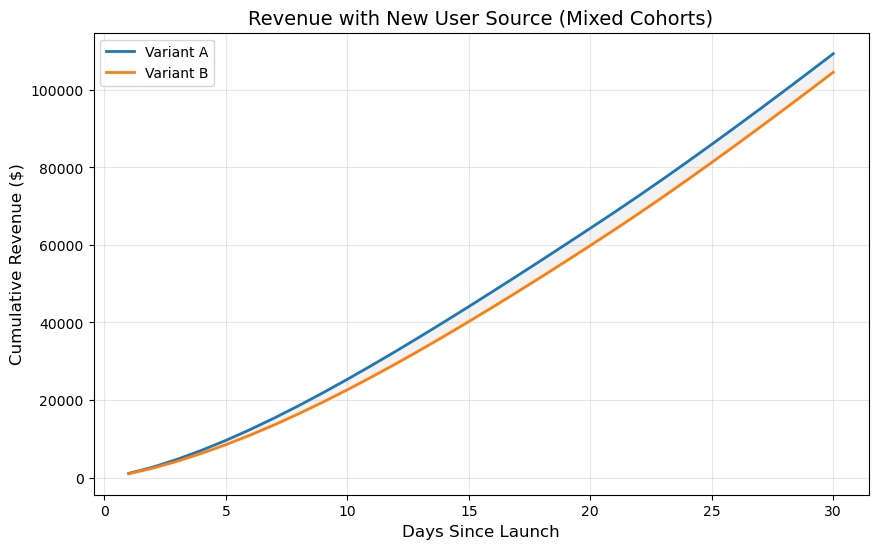

In [38]:
# --- Cell (e): Mixed Cohort Simulation (New User Source from Day 20) ---

# Switch scenario constants (edit if needed)
SIMULATION_DAYS = 30
SWITCH_DAY = 20  # day 20 is the FIRST day the new regime applies; use 21 if "after day 20"
TOTAL_INSTALLS_PRE_SWITCH = 20000
OLD_INSTALLS_POST_SWITCH = 12000
NEW_INSTALLS_POST_SWITCH = 8000

rev_a_new, hist_a_new = RevenueSimulator.run_mixed_cohort_simulation(
    variant=var_a,
    new_retention_func=exponential_decay_a,
    simulation_days=SIMULATION_DAYS,
    switch_day=SWITCH_DAY,
    total_installs_pre_switch=TOTAL_INSTALLS_PRE_SWITCH,
    old_installs_post_switch=OLD_INSTALLS_POST_SWITCH,
    new_installs_post_switch=NEW_INSTALLS_POST_SWITCH,
    assumed_arppu=ASSUMED_ARPPU,
)

rev_b_new, hist_b_new = RevenueSimulator.run_mixed_cohort_simulation(
    variant=var_b,
    new_retention_func=exponential_decay_b,
    simulation_days=SIMULATION_DAYS,
    switch_day=SWITCH_DAY,
    total_installs_pre_switch=TOTAL_INSTALLS_PRE_SWITCH,
    old_installs_post_switch=OLD_INSTALLS_POST_SWITCH,
    new_installs_post_switch=NEW_INSTALLS_POST_SWITCH,
    assumed_arppu=ASSUMED_ARPPU,
)

print(f"--- Task (e): Revenue with New User Source (Day 30) ---")
print(f"{var_a.name}: ${rev_a_new:,.2f}")
print(f"{var_b.name}: ${rev_b_new:,.2f}")
print(f"WINNER: {var_a.name if rev_a_new > rev_b_new else var_b.name}")

Visualizer.plot_revenue_race(hist_a_new, hist_b_new, "Revenue with New User Source (Mixed Cohorts)")


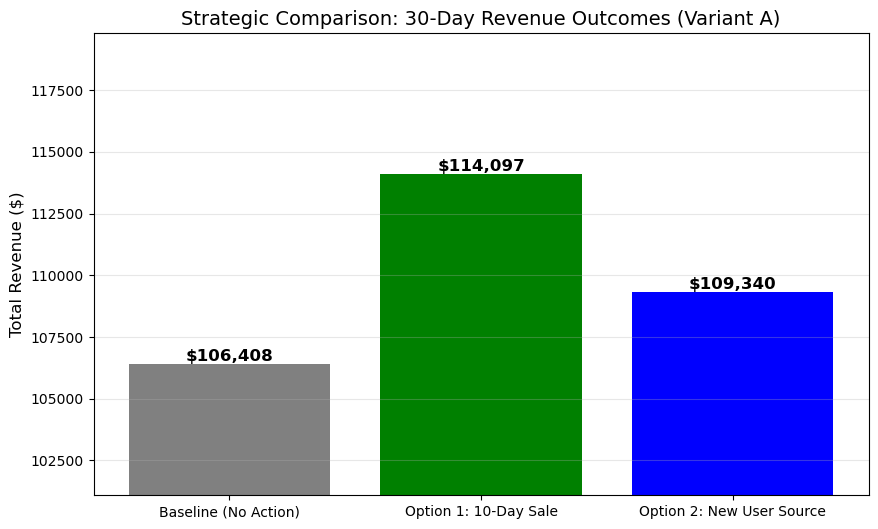

In [39]:
# --- Cell (f): Decision Support (Variant A) ---

options = {
    "Baseline (No Action)": rev_a_30,
    "Option 1: 10-Day Sale": sale_rev_a,
    "Option 2: New User Source": rev_a_new,
}

Visualizer.plot_option_comparison(
    options=options,
    title="Strategic Comparison: 30-Day Revenue Outcomes (Variant A)",
    ylabel="Total Revenue ($)"
)

STRATEGIC RECOMMENDATION:
1. Short Term Winner: The 10-Day Sale generates the highest 30-day revenue ($122,767).
2. Long Term Winner: The New User Source ($117,923).

DECISION: Prioritize the NEW USER SOURCE.
Reasoning:
- The Sale is a temporary event. Once it ends on Day 24, revenue per user reverts to baseline.
- The New Source improves retention permanently. While it generates slightly less cash
  in the first 30 days (due to the late start on Day 20), its compound value (LTV)
  will surpass the sale significantly in Months 2 and 3.